## Exportacion de modelo de ONNX - Clasificación de Aprobación de Préstamo

En este notebook, se describe el flujo de trabajo ejecutado para el entrenamiento, evaluación y exportación de un modelo de Machine Learning diseñado para predecir la aprobación de préstamos.

El conjunto de datos utilizado proviene de Kaggle y consta de 45,000 registros y 14 columnas (13 características y 1 variable objetivo).

El dataset sintético de 10,000 registros simula condiciones reales de la industria. Cada fila representa un punto de datos de una máquina. El objectivo es exportar un modelo de ONNX para ejecutar inferencia en C#.

Enlace de conjunto de datos: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data

### 1. Importación de Librerías y Carga de Datos

En la primera sección del código, se importan las herramientas de manipulación de datos (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`), preprocesamiento y modelado espacial (`scikit-learn`), así como las librerías necesarias para la exportación del modelo a ONNX (`skl2onnx`).

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType, StringTensorType, Int64TensorType

Los datos se cargan desde el archivo local `../data/loan_data.csv` en un DataFrame de Pandas.

In [10]:
data = pd.read_csv('../data/loan_data.csv')
data

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


De acuerdo con la teoría de Machine Learning, un modelo representa una función que se utiliza para predecir nuevos valores (etiquetas o labels $y$) a partir de un conjunto de observaciones o características (features $x$).

En este proyecto, abordamos simultáneamente los dos tipos principales de problemas de aprendizaje supervisado:
- Problema de Clasificación: El objetivo es predecir una etiqueta discreta y mutuamente excluyente. En nuestro caso, predecimos la variable loan_status para determinar si un préstamo es Aprobado (1) o Rechazado (0).
- Problema de Regresión: El objetivo es predecir un valor numérico continuo. En este proyecto, estimamos el credit_score (Puntaje Crediticio) basándonos en el perfil del solicitante.

Al extraer loan_status y credit_score del conjunto de datos original, el resto de las columnas se convierten en nuestras variables de entrada ($X$).

### 2. Análisis exploratorio de datos (EDA)

Antes del modelado, se realiza una exploración profunda para comprender la estructura de los datos:
- Se identifican los tipos de variables (categóricas vs. numéricas).
- Se analizan distribuciones y la presencia de valores atípicos.
- En el caso de la clasificación (loan_status), se revisa el balanceo de clases.
- En el caso de la regresión (credit_score), se visualiza la distribución de la variable continua.

Mediante `data.info()` y `data.describe().T`, se observa que el conjunto contiene datos numéricos (float64, int64) y categóricos (str).

| Column                         | Descripción                                                      | Tipo    |
|--------------------------------|------------------------------------------------------------------|---------|
| person_age                     | Edad de la persona                                               | float64 |
| person_gender                  | Género de la persona                                             | str     |
| person_education               | Nivel de educación más alto                                      | str     | 
| person_income                  | Salario anual                                                    | float64 | 
| person_emp_exp                 | Años de experiencia laboral                                      | int64   |
| person_home_ownership          | Estado de propiedad del hogar (por ejemplo, rent, own, mortgage) | str     | 
| loan_amnt                      | Importe del préstamo solicitado                                  | float64 |
| loan_intent                    | Propósito del préstamo                                           | str     |
| loan_int_rate                  | Tarifa de interés del préstamo                                   | float64 |
| loan_percent_income            | Importe del préstamo como porcentaje del salario anual           | float64 |
| cb_person_cred_hist_length     | Duración del historial crediticio en años                        | float64 |
| credit_score                   | Puntaje de crédito de la persona                                 | int64   | 
| previous_loan_defaults_on_file | Indicador de impagos de préstamos anteriores                     | str     | 
| loan_status                    | Estado de aprobación del préstamo: 1 = aprobado; 0 = rechazado   | int64   | 


In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [12]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


Se verifica la existencia de valores faltantes calculando el porcentaje con `.isnull().mean()`, mostrando que el dataset no presenta valores nulos iniciales en ninguna de sus columnas

<Axes: >

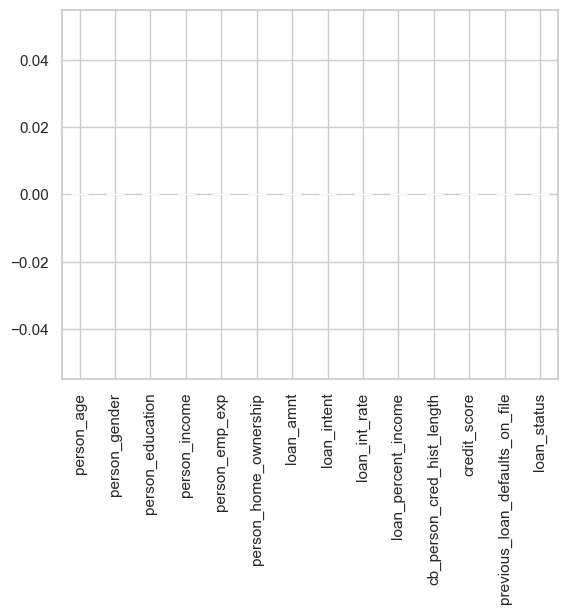

In [13]:
missing_counts = data.isnull().sum()
missing_counts.plot(kind='bar')

In [14]:
missing_percent = data.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

person_age                        0.0
person_gender                     0.0
person_education                  0.0
person_income                     0.0
person_emp_exp                    0.0
person_home_ownership             0.0
loan_amnt                         0.0
loan_intent                       0.0
loan_int_rate                     0.0
loan_percent_income               0.0
cb_person_cred_hist_length        0.0
credit_score                      0.0
previous_loan_defaults_on_file    0.0
loan_status                       0.0
dtype: float64

Se grafica un countplot de la columna loan_status (0 = Rechazado, 1 = Aprobado), revelando un desbalance de clases (hay más préstamos rechazados que aprobados). Se genera una histograma para credit_score, revelando un puntaje de cada registro. Por lo tanto, hay dos columnas de target, una de clasificación y otra de regresión. 

Text(0.5, 1.0, 'Distribución de la Aprobación del Préstamo (0 = Rechazado, 1 = Aprobado)')

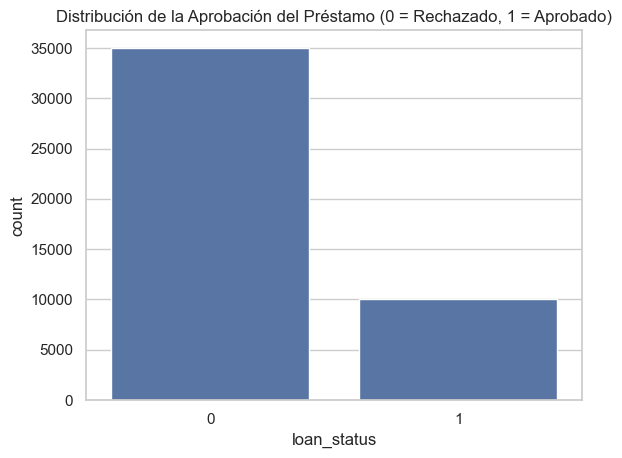

In [15]:
sns.countplot(data=data, x="loan_status")
plt.title("Distribución de la Aprobación del Préstamo (0 = Rechazado, 1 = Aprobado)")

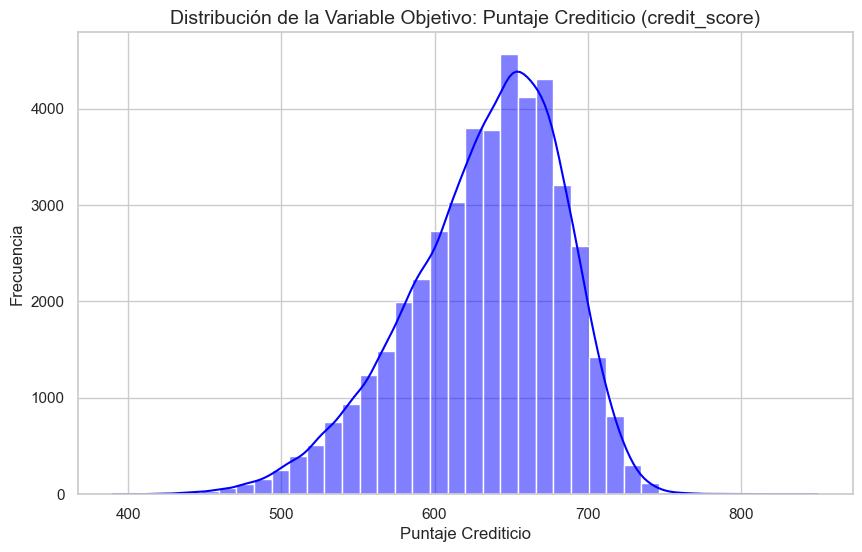

Resumen Estadístico de credit_score:
count    45000.000000
mean       632.608756
std         50.435865
min        390.000000
25%        601.000000
50%        640.000000
75%        670.000000
max        850.000000
Name: credit_score, dtype: float64


In [16]:
# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Histograma y curva de densidad (KDE)
plt.figure(figsize=(10, 6))
sns.histplot(data['credit_score'], bins=40, kde=True, color='blue')
plt.title('Distribución de la Variable Objetivo: Puntaje Crediticio (credit_score)', fontsize=14)
plt.xlabel('Puntaje Crediticio')
plt.ylabel('Frecuencia')
plt.show()

# Resumen estadístico
print("Resumen Estadístico de credit_score:")
print(data['credit_score'].describe())

Para la clasificación, se generan histogramas para variables numéricas (como person_age, loan_amnt, person_income) y gráficos de barras para las variables categóricas (como person_gender, person_education).

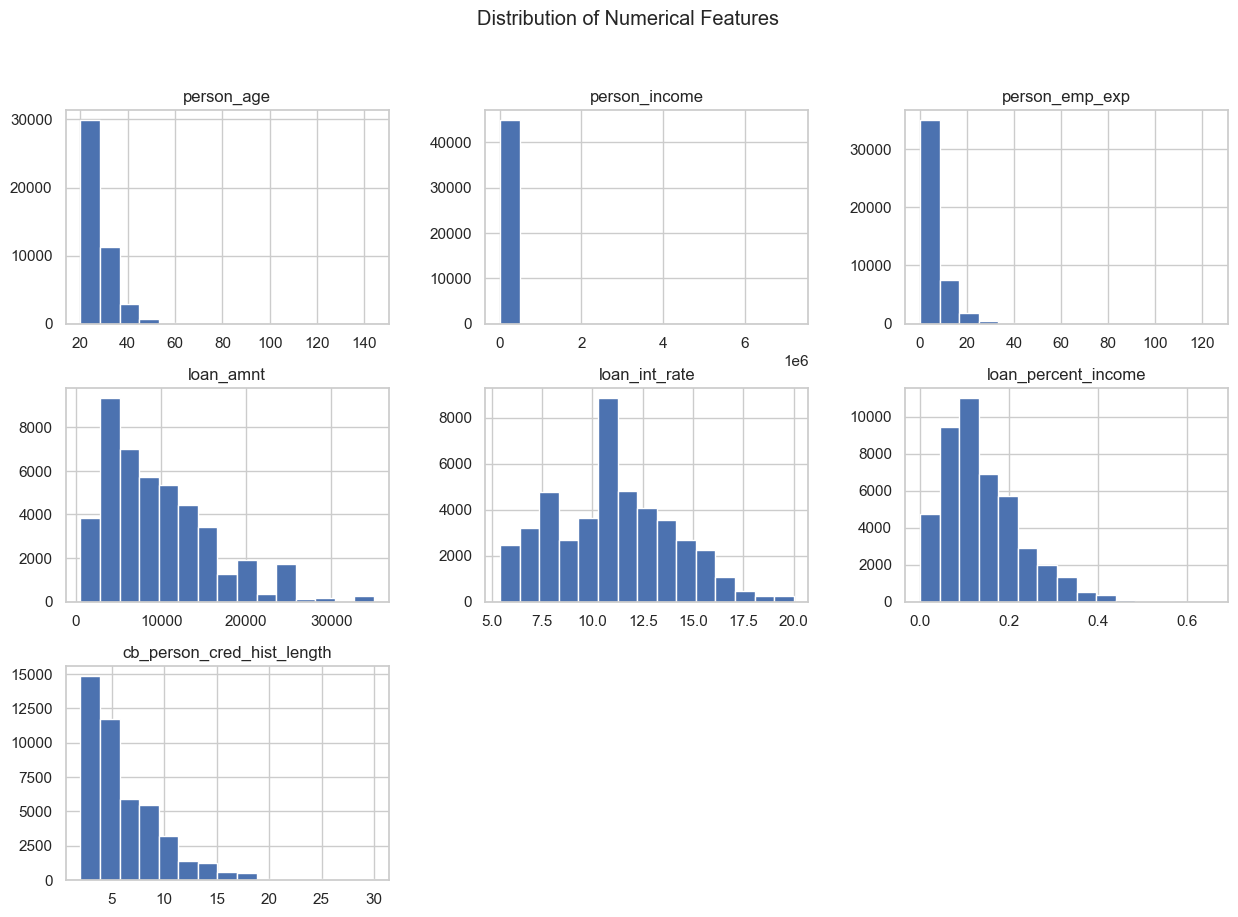

In [17]:
numerical_features = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 
                      'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

data[numerical_features].hist(bins=15, figsize=(15, 10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

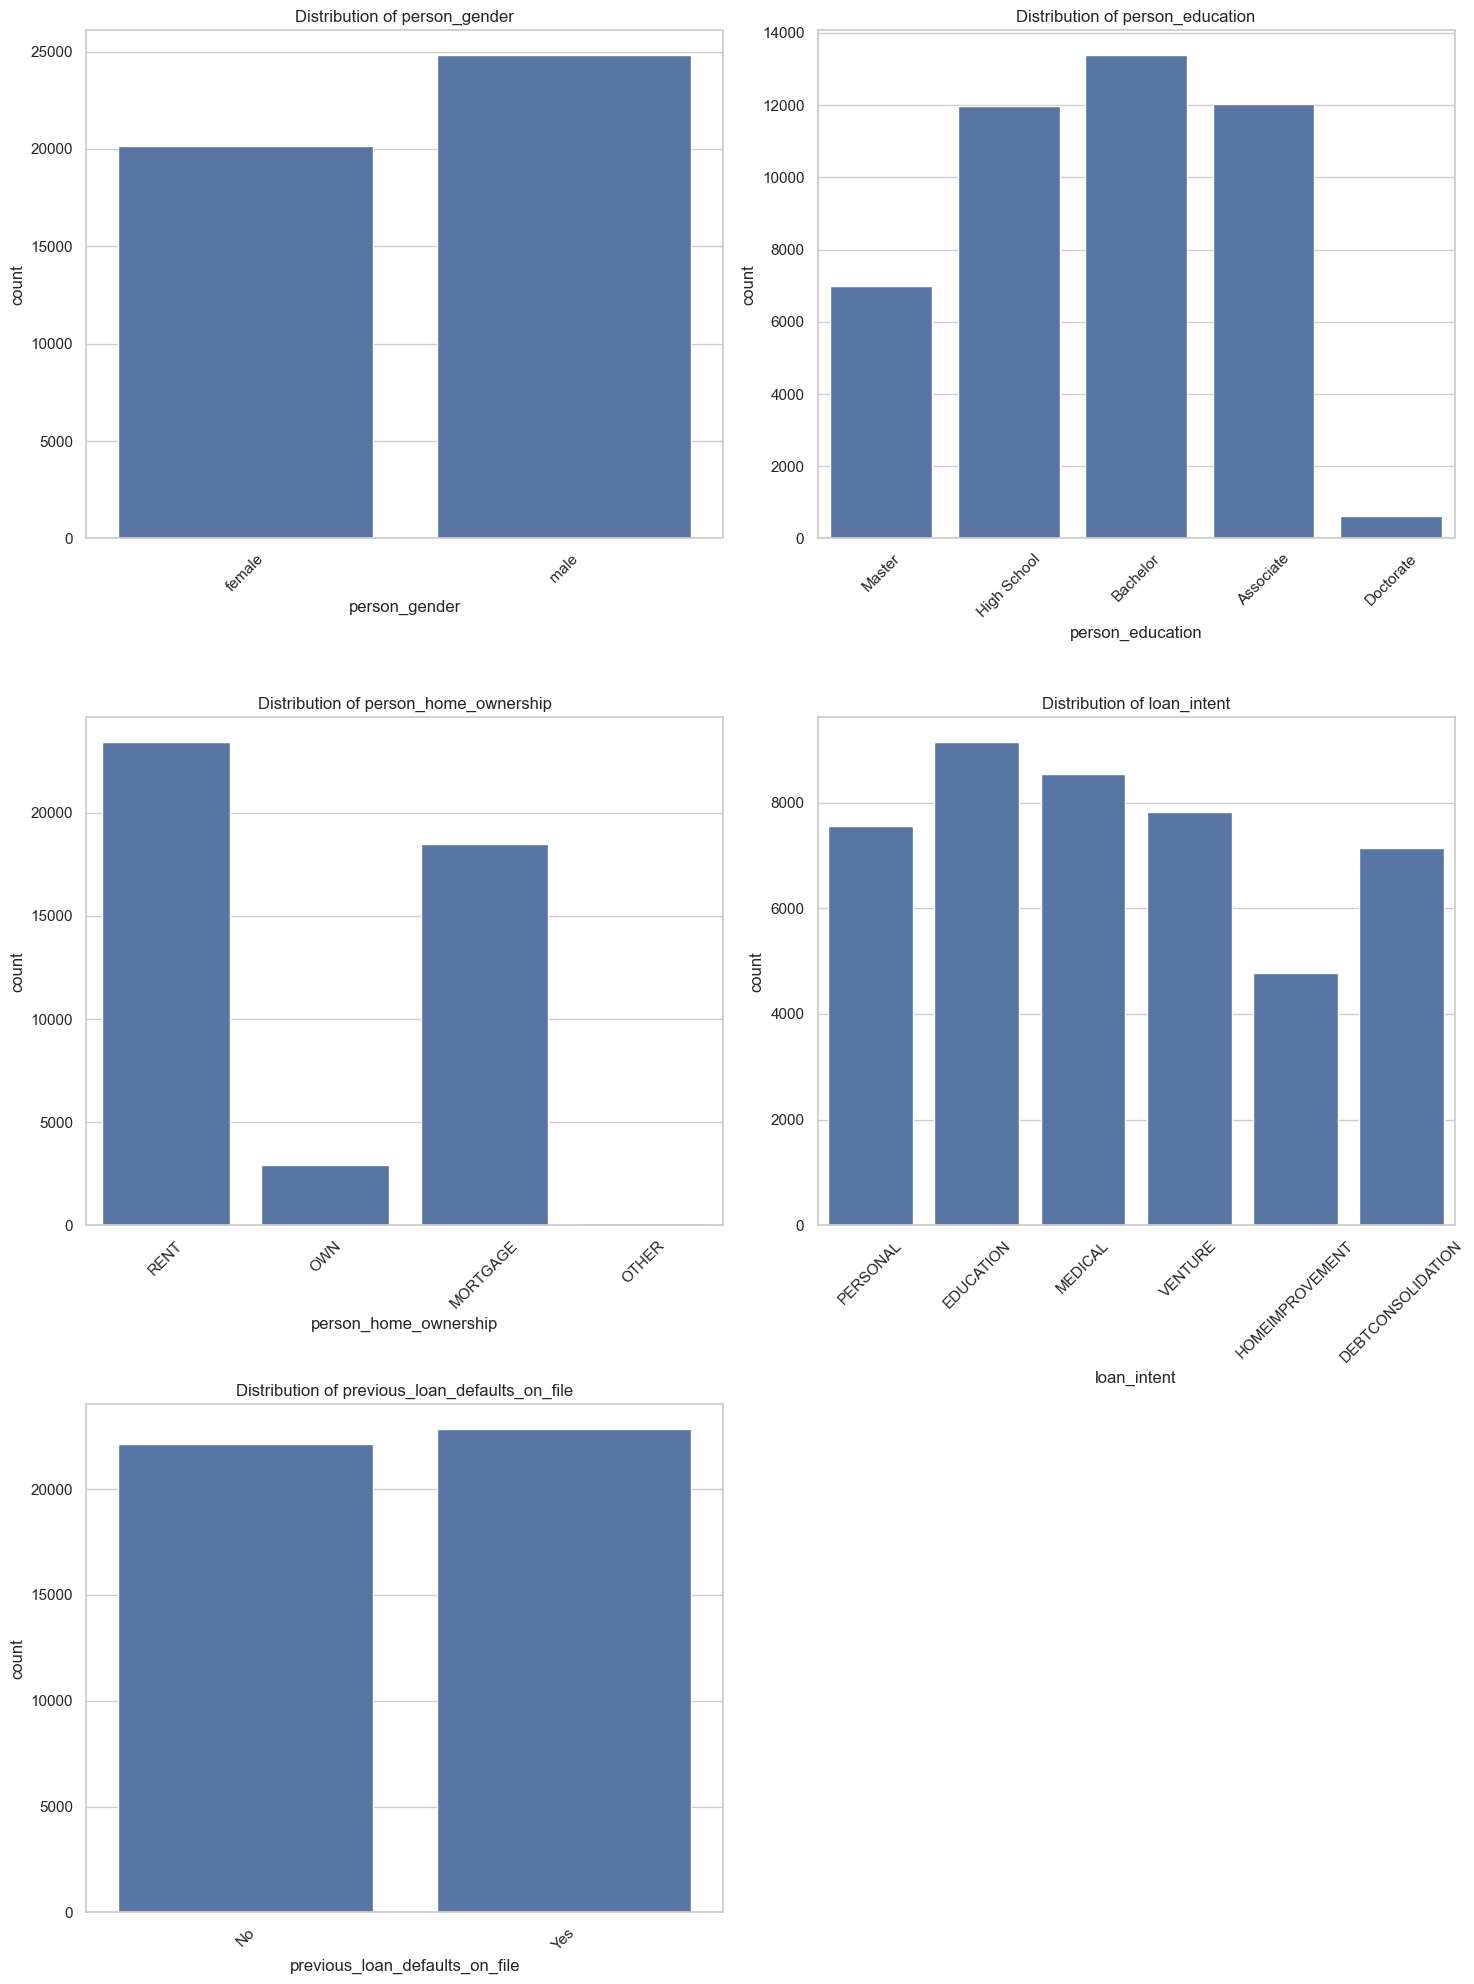

In [18]:
categorical_features = ["person_gender", "person_education", "person_home_ownership", "loan_intent", "previous_loan_defaults_on_file"]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 20))

axes = axes.ravel()

for i, feature in enumerate(categorical_features):
    sns.countplot(data=data, x=feature, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar subplots sobrantes
for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


Se explora la relación entre cada característica y la variable objetivo `loan_status` utilizando diagramas de caja (boxplots) para las variables numéricas y gráficos de conteo apilados por color (hue) para las categóricas.

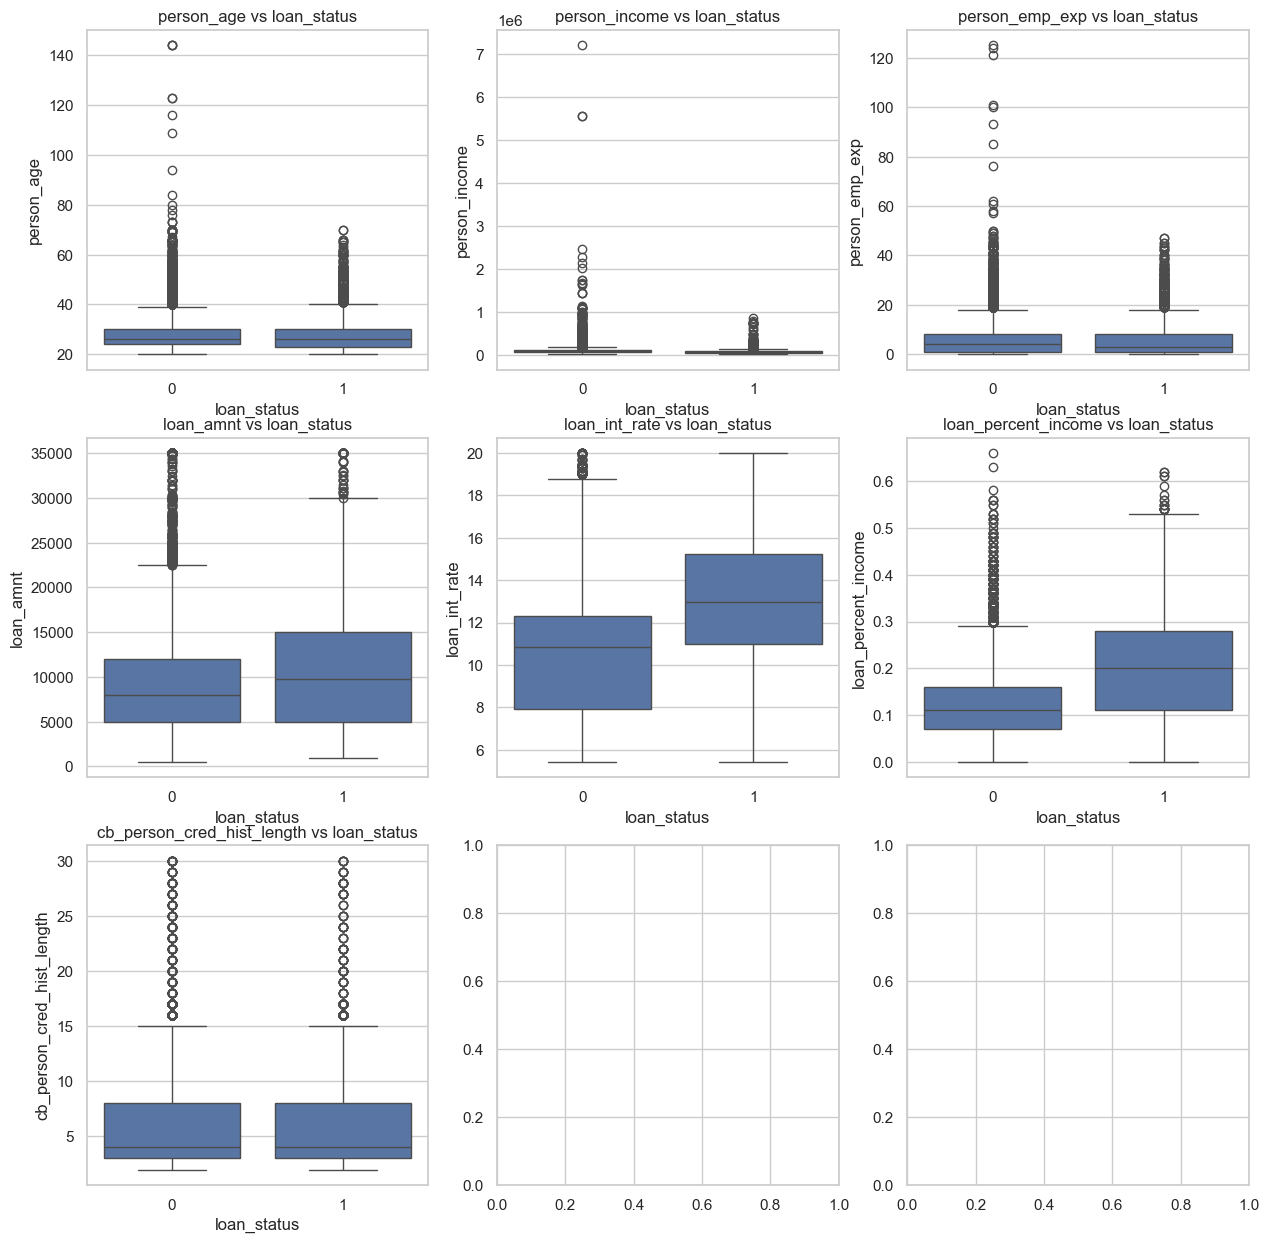

In [19]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

for ax, feature in zip(axes.ravel(), numerical_features):
    sns.boxplot(data=data, x="loan_status", y=feature, ax=ax)
    ax.set_title(f"{feature} vs loan_status")

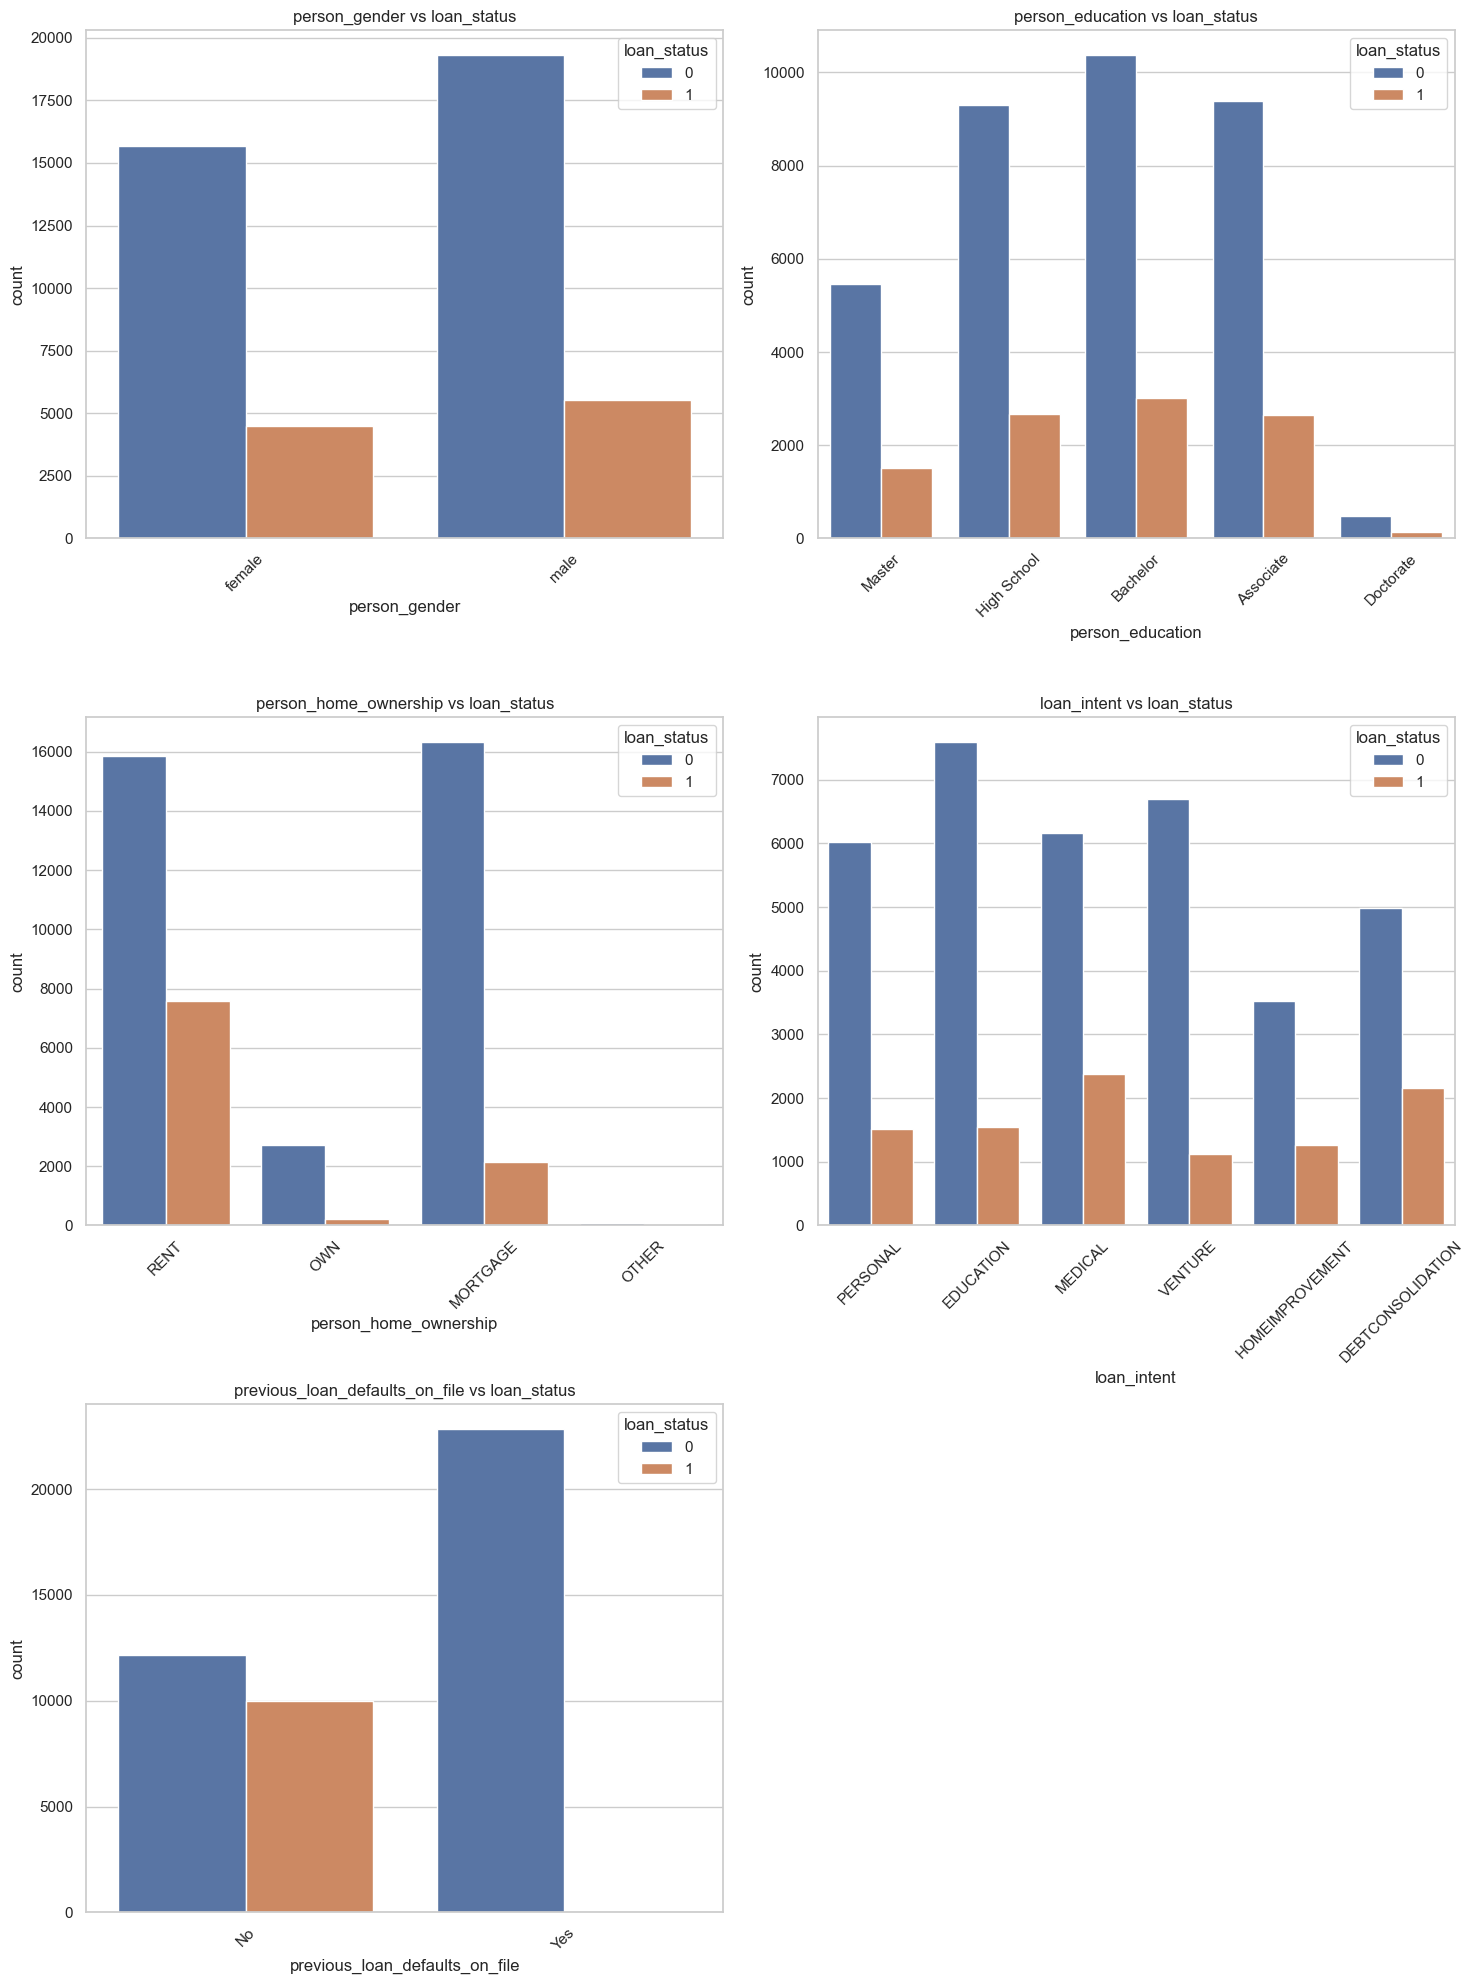

In [20]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 20))

axes = axes.ravel()

for i, feature in enumerate(categorical_features):
    sns.countplot(data=data, x=feature, hue="loan_status", ax=axes[i])
    axes[i].set_title(f"{feature} vs loan_status")
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar subplots sobrantes
for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

Para la regresión, la correlación de Pearson es fundamental. Queremos ver qué variables numéricas (como ingresos, edad, monto del préstamo) tienen la relación matemática más fuerte con el credit_score

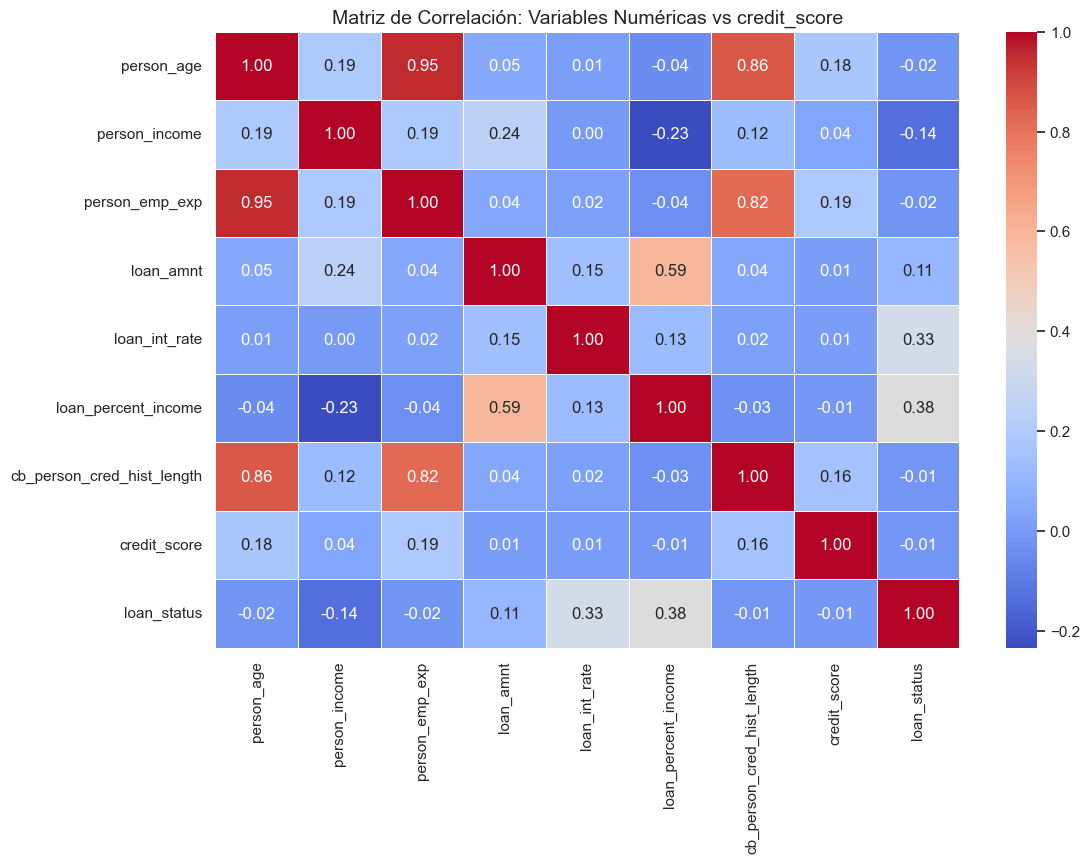

In [21]:
# Seleccionar solo las columnas numéricas
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
correlation_matrix = numeric_data.corr()

# Graficar un Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Variables Numéricas vs credit_score', fontsize=14)
plt.show()

Basándonos en las numéricas más importantes, usamos gráficos de dispersión (scatter plots) para buscar patrones visuales entre la variable independiente y el puntaje crediticio.

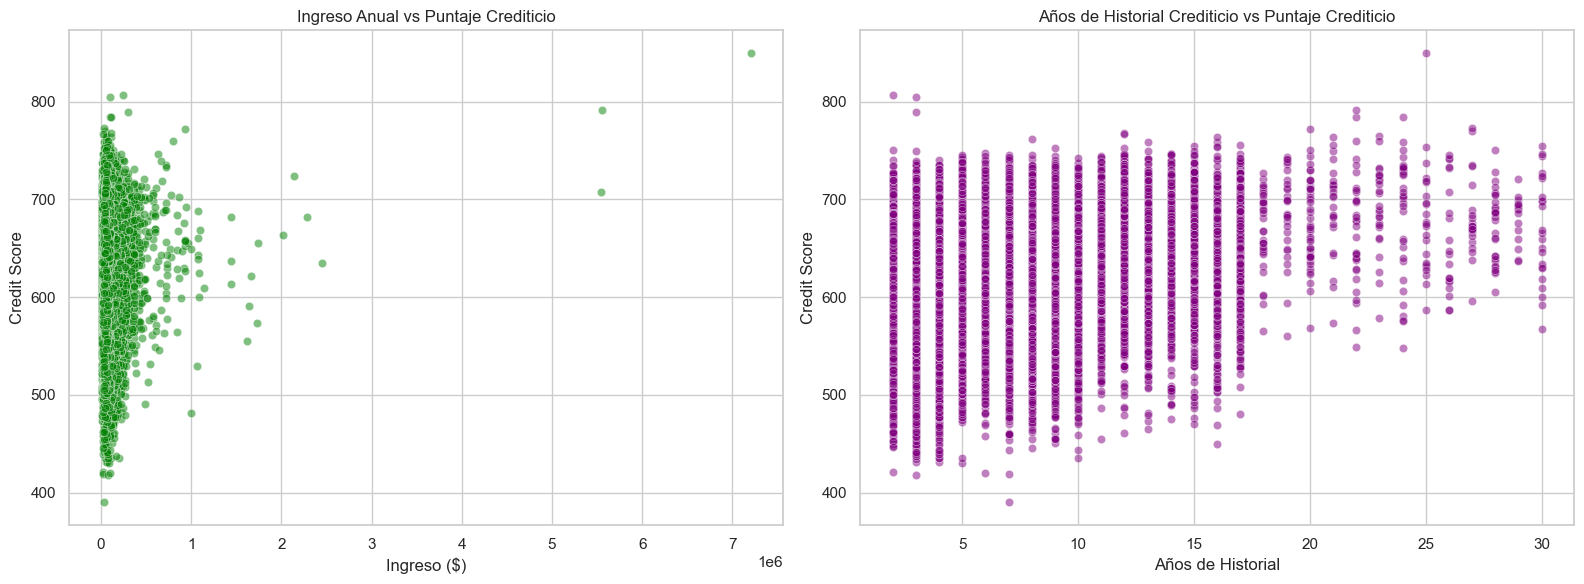

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ingreso vs Puntaje
sns.scatterplot(x='person_income', y='credit_score', data=data, ax=axes[0], alpha=0.5, color='green')
axes[0].set_title('Ingreso Anual vs Puntaje Crediticio')
axes[0].set_xlabel('Ingreso ($)')
axes[0].set_ylabel('Credit Score')

# Longitud del historial crediticio vs Puntaje
sns.scatterplot(x='cb_person_cred_hist_length', y='credit_score', data=data, ax=axes[1], alpha=0.5, color='purple')
axes[1].set_title('Años de Historial Crediticio vs Puntaje Crediticio')
axes[1].set_xlabel('Años de Historial')
axes[1].set_ylabel('Credit Score')

plt.tight_layout()
plt.show()

Finalmente, necesitamos saber cómo afectan las variables de texto (que luego procesarás con el OneHotEncoder) al puntaje crediticio. Los gráficos de caja (boxplots) son ideales para esto.

C:\Users\hacki\AppData\Local\Temp\ipykernel_217472\3147307477.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='previous_loan_defaults_on_file', y='credit_score', data=data, ax=axes[0], palette='Set2')
C:\Users\hacki\AppData\Local\Temp\ipykernel_217472\3147307477.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='person_education', y='credit_score', data=data, ax=axes[1], palette='Set3')


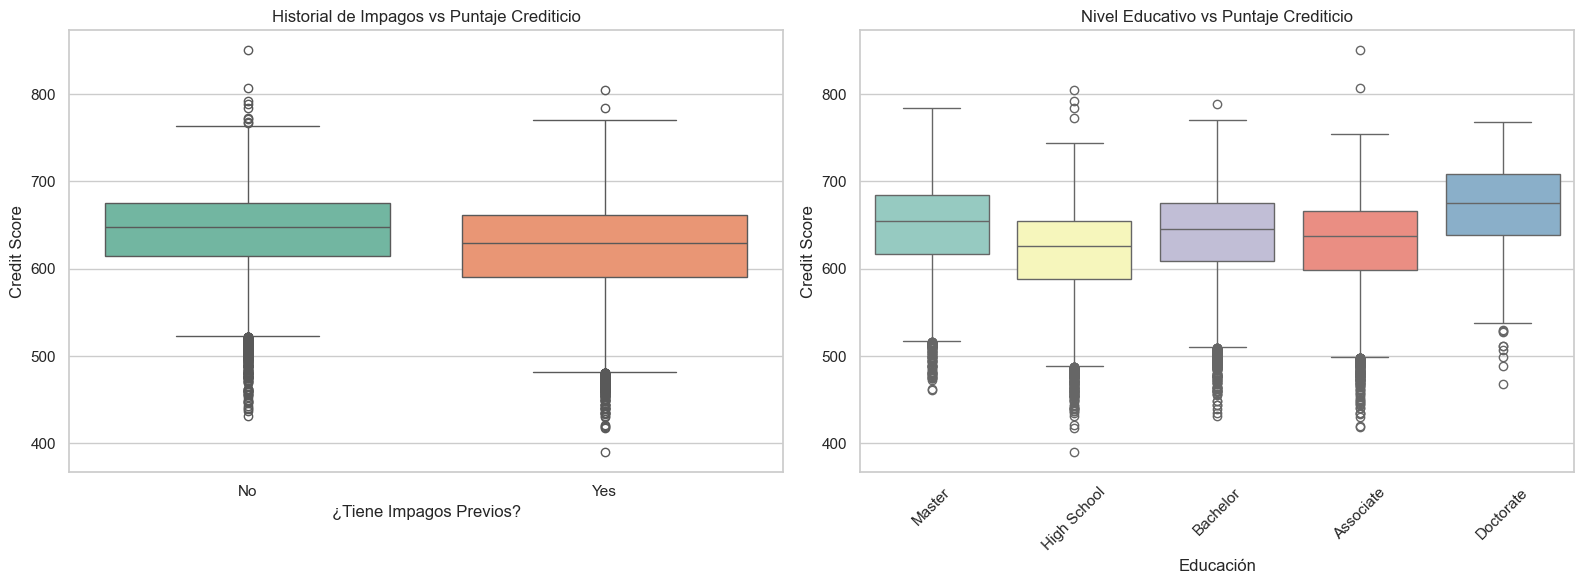

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Impagos previos vs Puntaje
sns.boxplot(x='previous_loan_defaults_on_file', y='credit_score', data=data, ax=axes[0], palette='Set2')
axes[0].set_title('Historial de Impagos vs Puntaje Crediticio')
axes[0].set_xlabel('¿Tiene Impagos Previos?')
axes[0].set_ylabel('Credit Score')

# Educación vs Puntaje
sns.boxplot(x='person_education', y='credit_score', data=data, ax=axes[1], palette='Set3')
axes[1].set_title('Nivel Educativo vs Puntaje Crediticio')
axes[1].set_xlabel('Educación')
axes[1].set_ylabel('Credit Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 3. Preprocesamiento de Datos

Para evitar la fuga de datos (data leakage) y mantener un flujo de trabajo ordenado y reproducible para producción, hacemos uso de Pipelines de Scikit-Learn. Un pipeline asegura que las mismas transformaciones aplicadas a los datos de entrenamiento se apliquen exactamente igual a los nuevos datos de inferencia.

Para evitar conflictos al exportar el modelo a ONNX, se fuerza la conversión de todas las columnas categóricas a tipo texto (**string**). Luego, se construyen transformadores (**Pipelines**) independientes:
 - **Variables Numéricas**: Se imputan posibles valores nulos usando la mediana (`SimpleImputer`) y se escalan mediante `StandardScaler`.
 - **Variables Categóricas Nominales**: Se imputan con el valor más frecuente y se codifican empleando `OneHotEncoder`.
 - **Variables Categóricas Ordinales** (Ej. Nivel de Educación): Se imputan con el valor más frecuente y se codifican manteniendo su jerarquía lógica a través de `OrdinalEncoder`.

Estos pasos se agrupan en un único `ColumnTransformer` que automatiza el proceso.


In [24]:
X = data.drop(columns=["loan_status", 'credit_score'])

y_class = data['loan_status']
y_reg = data['credit_score']

numerical_features = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 
                      'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
cat_nominal_features = ['person_gender', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
cat_ordinal_features = ['person_education']

# Definir el orden natural de la educación (de menor a mayor grado)
education_levels = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

# Convertir todas las columnas categóricas a tipo string. 
# Esto transforma los np.nan (float) en el texto 'nan' automáticamente.
X[cat_nominal_features] = X[cat_nominal_features].astype(str)
X[cat_ordinal_features] = X[cat_ordinal_features].astype(str)

# Preprocesamiento para datos numéricos
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Rellena nulos numéricos con la mediana
    ('scaler', StandardScaler())                   # Escala los datos
])

# Preprocesamiento para datos categóricos nominales
categorical_nominal_transformer = Pipeline(steps=[
    # Le decimos al imputer que busque el texto 'nan'
    ('imputer', SimpleImputer(missing_values='nan', strategy='most_frequent')), 
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocesamiento para datos categóricos ordinales
categorical_ordinal_transformer = Pipeline(steps=[
    # Le decimos al imputer que busque el texto 'nan'
    ('imputer', SimpleImputer(missing_values='nan', strategy='most_frequent')), 
    ('encoder', OrdinalEncoder(categories=education_levels, handle_unknown='use_encoded_value', unknown_value=-1))
])

# Unir ambos preprocesamientos en un ColumnTransformer
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat_nom', categorical_nominal_transformer, cat_nominal_features),
        ('cat_ord', categorical_ordinal_transformer, cat_ordinal_features)
    ])

In [25]:
X

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,previous_loan_defaults_on_file
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,No
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,Yes
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,No
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,No
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,No
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,No
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,No
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,No


### 4. Entrenamiento del Modelo

Se divide el conjunto en datos de entrenamiento (80%) y prueba (20%) utilizando `train_test_split` para mantener la proporción de las clases.

Debido a la naturaleza de nuestras variables predictivas, se entrenan dos flujos independientes utilizando ensambles basados en árboles:
- Pipeline de Clasificación: RandomForestClassifier para aprender la frontera de decisión lógica entre aprobar o rechazar el crédito.
- Pipeline de Regresión: RandomForestRegressor para encontrar la función matemática que mejor aproxime la calificación crediticia del usuario.

In [26]:
# ---- SPLIT ----
X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

_X_train, _X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)



X_train

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,previous_loan_defaults_on_file
25180,34.0,female,Bachelor,97265.0,11,MORTGAGE,15000.0,PERSONAL,12.73,0.15,9.0,No
12555,25.0,male,High School,72953.0,3,RENT,12000.0,VENTURE,11.86,0.16,4.0,Yes
29153,41.0,female,Master,322597.0,18,MORTGAGE,24000.0,PERSONAL,10.37,0.07,11.0,Yes
23838,27.0,male,Associate,94232.0,4,RENT,9600.0,EDUCATION,17.14,0.10,7.0,No
35686,27.0,male,Master,84873.0,7,RENT,7059.0,HOMEIMPROVEMENT,12.97,0.08,3.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
11284,26.0,male,High School,88451.0,6,MORTGAGE,10625.0,EDUCATION,6.03,0.12,4.0,Yes
44732,25.0,female,High School,34772.0,3,MORTGAGE,5876.0,HOMEIMPROVEMENT,11.69,0.17,4.0,No
38158,33.0,female,Associate,58317.0,9,MORTGAGE,10707.0,VENTURE,10.74,0.18,9.0,Yes
860,26.0,male,Master,178602.0,6,RENT,20000.0,DEBTCONSOLIDATION,17.99,0.11,3.0,No


In [27]:
x_train_class_processed = preprocessing_pipeline.fit_transform(X_train, y_class_train)
x_train_class_processed

array([[ 1.03947529,  0.19422493,  0.93118562, ...,  1.        ,
         0.        ,  2.        ],
       [-0.4561859 , -0.089962  , -0.39501412, ...,  0.        ,
         1.        ,  0.        ],
       [ 2.20276733,  2.82816736,  2.0916104 , ...,  0.        ,
         1.        ,  3.        ],
       ...,
       [ 0.87329072, -0.26104458,  0.59963569, ...,  0.        ,
         1.        ,  1.        ],
       [-0.29000132,  1.14498636,  0.10231078, ...,  1.        ,
         0.        ,  3.        ],
       [-0.29000132,  1.52245281, -0.22923915, ...,  0.        ,
         1.        ,  0.        ]], shape=(36000, 22))

In [28]:
x_train_reg_processed = preprocessing_pipeline.fit_transform(X_train, y_reg_train)
x_train_reg_processed

array([[ 1.03947529,  0.19422493,  0.93118562, ...,  1.        ,
         0.        ,  2.        ],
       [-0.4561859 , -0.089962  , -0.39501412, ...,  0.        ,
         1.        ,  0.        ],
       [ 2.20276733,  2.82816736,  2.0916104 , ...,  0.        ,
         1.        ,  3.        ],
       ...,
       [ 0.87329072, -0.26104458,  0.59963569, ...,  0.        ,
         1.        ,  1.        ],
       [-0.29000132,  1.14498636,  0.10231078, ...,  1.        ,
         0.        ,  3.        ],
       [-0.29000132,  1.52245281, -0.22923915, ...,  0.        ,
         1.        ,  0.        ]], shape=(36000, 22))

Se crea un pipeline global con `make_pipeline` que ensambla el preprocesador construido en el paso anterior y unos estimadores `RandomForestClassifier` con 100 árboles de decisión (`n_estimators=100`), y `GradientBoostingRegressor`.

In [29]:
model_class = RandomForestClassifier(n_estimators=100, random_state=42)
model_class.fit(x_train_class_processed, y_class_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
model_reg = GradientBoostingRegressor(random_state=42)
model_reg.fit(x_train_reg_processed, y_reg_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Se entrena el pipeline completo invocando `.fit(X_train, y_train)`.

In [31]:
pipeline_class = make_pipeline(preprocessing_pipeline, model_class)
pipeline_class.fit(X_train, y_class_train)

,steps,"[('columntransformer', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_nom', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
pipeline_reg = make_pipeline(preprocessing_pipeline, model_reg)
pipeline_reg.fit(X_train, y_reg_train)

,steps,"[('columntransformer', ...), ('gradientboostingregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_nom', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 5. Evaluación del Modelo

Los modelos se evalúan utilizando el conjunto de prueba aislado (X_test), empleando las métricas adecuadas para cada tipo de problema:

Métricas del Modelo de Regresión (credit_score):
- MAE (Error Absoluto Medio): Promedio de los errores absolutos en la predicción del puntaje.
- RMSE (Raíz del Error Cuadrático Medio): Penaliza severamente predicciones de puntaje que se alejan mucho del valor real.
- R² (Coeficiente de Determinación): Mide qué proporción de la varianza en el puntaje crediticio es explicada por las variables de entrada.

In [33]:
# --- EVALUACIÓN REGRESIÓN (Credit Score) ---
y_reg_pred = pipeline_reg.predict(X_test)
print("=== REGRESIÓN: PUNTAJE DE CRÉDITO ===")
print(f"MSE (Error Cuadrático Promedio): {mean_squared_error(y_reg_test, y_reg_pred):.4f}")
print(f"MAE (Error Absoluto Medio): {mean_absolute_error(y_reg_test, y_reg_pred):.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {root_mean_squared_error(y_reg_test, y_reg_pred):.4f}")
print(f"R2 Score: {r2_score(y_reg_test, y_reg_pred):.4f}")

=== REGRESIÓN: PUNTAJE DE CRÉDITO ===
MSE (Error Cuadrático Promedio): 2325.7764
MAE (Error Absoluto Medio): 38.5892
RMSE (Raíz del Error Cuadrático Medio): 48.2263
R2 Score: 0.1107


Métricas del Modelo de Clasificación (loan_status):
- Se evalúa el número de predicciones correctas mediante la Exactitud (Accuracy) y se genera un reporte detallando Precisión (Precision), Sensibilidad (Recall) y el F1-Score.
- Se utiliza una Matriz de Confusión para visualizar los verdaderos positivos/negativos frente a los errores del algoritmo.

In [34]:
# --- EVALUACIÓN CLASIFICACIÓN (Loan Status) ---
y_class_pred = pipeline_class.predict(X_test)
print("=== CLASIFICACIÓN: ESTADO DEL PRÉSTAMO ===")
print(f"Accuracy: {accuracy_score(y_class_test, y_class_pred):.4f}")
print(f"Precision: {precision_score(y_class_test, y_class_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_class_test, y_class_pred, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_class_test, y_class_pred, average='weighted'):.4f}")
print("Reporte de Clasificación:")
print(classification_report(y_class_test, y_class_pred))

=== CLASIFICACIÓN: ESTADO DEL PRÉSTAMO ===
Accuracy: 0.9283
Precision: 0.9270
Recall: 0.9283
F1 Score: 0.9264
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      6990
           1       0.89      0.77      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



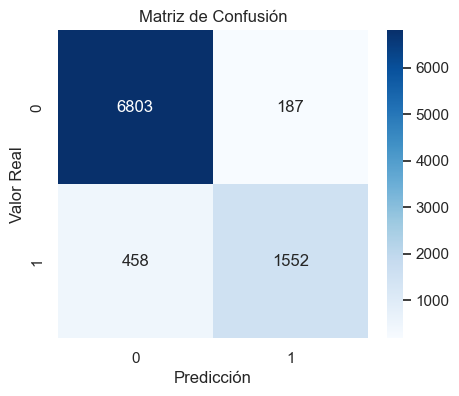

In [35]:
# Matriz de Confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_class_test, y_class_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

El modelo de clasificación logró una exactitud general del 92.83%. Se genera un reporte de clasificación mostrando precisión de 92.7%, recuerdo de 92.83%, y puntuación de F1 de 92.64% promedio ponderados. Minetras el uno de regresión logró un error cuádratico promedio del 2325.78, el uno absoluto medio de 38.58, una raíz del error cuadrático medio de 48.22, y el R2 Score de 11.07%. Para la Matriz de Confusión, se traza un mapa de calor (heatmap) ilustrando los verdaderos positivos/negativos contra los falsos positivos/negativos. Finalmente, los valores predichos y los reales se añaden como nuevas columnas al DataFrame de prueba para una inspección visual manual.

### 6. Serializacion de ONNX

Como paso final en el ciclo de vida del modelo de ML, requerimos que los modelos entrenados puedan consumirse desde otra plataforma fuera de Python como una aplicación gráfica en C# que ejecute inferencias en tiempo real de forma nativa

Para lograr la interoperabilidad:
- Se utiliza la función `convert_sklearn` especificando el modelo, los tipos iniciales y asegurando la compatibilidad.
- Se mapean explícitamente los tensores de entrada determinando si cada característica es un texto (StringTensorType), un entero (Int64TensorType) o un decimal (FloatTensorType).
- Se exportan ambos pipelines de forma independiente (`loan_status_model.onnx` y `credit_score_model.onnx`) utilizando el estándar abierto ONNX (Open Neural Network Exchange).


In [36]:
# Unimos tus listas de características categóricas
categorical_cols = cat_nominal_features + cat_ordinal_features

# Declarar los tipos iniciales dinámicamente
initial_types = []
for col in X.columns:
    if col in categorical_cols:
        initial_types.append((col, StringTensorType([None, 1])))
    elif X[col].dtype == 'int64':
        initial_types.append((col, Int64TensorType([None, 1])))
    else:
        initial_types.append((col, FloatTensorType([None, 1])))


path = "../models"

if not os.path.exists(path):
    os.makedirs(path)

# ------------------------------
# Convertir el modelo de classificación
# ------------------------------
onnx_class_model = convert_sklearn(
    pipeline_class,
    initial_types=initial_types
)

with open(os.path.join(path, "loan_status_model.onnx"), "wb") as f:
    f.write(onnx_class_model.SerializeToString())

# ------------------------------
# Convertir el modelo de regresión
# ------------------------------
onnx_reg_model = convert_sklearn(
    pipeline_reg,
    initial_types=initial_types
)

with open(os.path.join(path, "credit_score_model.onnx"), "wb") as f:
    f.write(onnx_reg_model.SerializeToString())

print("¡Ambos modelos exportados exitosamente a la carpeta 'models'!")

¡Ambos modelos exportados exitosamente a la carpeta 'models'!
